# 🍷 End-to-End Multiclass Pipeline with `model_track`

This notebook demonstrates the **complete multiclass modeling workflow** using the `model_track` library — from raw data to model evaluation and context persistence.

We use the classic **Wine dataset** (scikit-learn): 13 continuous features, 3 wine classes (`Barolo`, `Grignolino`, `Barbera`), 178 samples.

## Pipeline Overview

```
Raw Data
  └─► 1. Data Setup & Split
        └─► 2. Data Auditing (DataAuditor, TypeDetector)
              └─► 3. Binning (QuantileBinner)
                    └─► 4. Feature Selection (MulticlassSelector)
                          └─► 5. WoE Engineering (OvRWoeAdapter)
                                └─► 6. Model Training (LightGBM)
                                      └─► 7. Evaluation (MulticlassEvaluator)
                                            └─► 8. Context Persistence (ProjectContext)
```

## 📦 Imports

In [1]:
from datetime import datetime

import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# model_track — public API only
from model_track import ProjectContext, TaskType
from model_track.binning import QuantileBinner
from model_track.evaluation import MulticlassEvaluator
from model_track.preprocessing import DataAuditor, TypeDetector
from model_track.stats import MulticlassSelector
from model_track.woe import OvRWoeAdapter

print("All imports OK ✅")

All imports OK ✅


---
## 1. 📂 Data Setup & Train/OOT Split

We load the Wine dataset and split into a **development set** (70%) for fitting all transformers and the model, and an **OOT (Out-of-Time) set** (30%) simulating unseen production data.

In [2]:
# Load Wine dataset
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df = df.rename(columns={"target": "wine_class"})

# Map numeric classes to meaningful labels
class_names = {0: "Barolo", 1: "Grignolino", 2: "Barbera"}
df["wine_class"] = df["wine_class"].map(class_names)

TARGET = "wine_class"
CLASSES = list(class_names.values())
FEATURES = [c for c in df.columns if c != TARGET]

print(f"Dataset shape: {df.shape}")
print(f"Classes: {CLASSES}")
print("\nClass distribution:")
print(df[TARGET].value_counts().to_string())
df.head()

Dataset shape: (178, 14)
Classes: ['Barolo', 'Grignolino', 'Barbera']

Class distribution:
wine_class
Grignolino    71
Barolo        59
Barbera       48


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,Barolo
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,Barolo
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,Barolo
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,Barolo
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,Barolo


In [3]:
# Stratified split: 70% dev, 30% OOT
df_dev, df_oot = train_test_split(df, test_size=0.30, random_state=42, stratify=df[TARGET])
df_dev = df_dev.reset_index(drop=True)
df_oot = df_oot.reset_index(drop=True)

print(f"Dev set  : {len(df_dev):4d} rows")
print(f"OOT set  : {len(df_oot):4d} rows")

Dev set  :  124 rows
OOT set  :   54 rows


---
## 2. 🔍 Data Auditing

`DataAuditor` provides a statistical summary — missing values, data types, cardinality. `TypeDetector` classifies each feature as numerical or categorical, informing downstream binning decisions.

In [4]:
# Statistical summary of the dev set
auditor = DataAuditor()
summary = auditor.get_summary(df_dev)
print("📊 Data Audit Summary:")
summary

📊 Data Audit Summary:


,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
column_name,,,,,,,,,
alcohol,float64,0,0.0,98,11.03,14.38,13.05,4.032258,Too many values...
malic_acid,float64,0,0.0,100,0.89,5.80,1.67,3.225806,Too many values...
ash,float64,0,0.0,69,1.70,3.23,2.3,5.645161,Too many values...
alcalinity_of_ash,float64,0,0.0,49,12.00,30.00,20.0,9.677419,Too many values...
magnesium,float64,0,0.0,46,70.00,151.00,101.0,7.258065,Too many values...
total_phenols,float64,0,0.0,82,0.98,3.85,2.2,4.032258,Too many values...
flavanoids,float64,0,0.0,102,0.34,5.08,0.58,2.419355,Too many values...
nonflavanoid_phenols,float64,0,0.0,35,0.13,0.66,0.43,6.451613,Too many values...
proanthocyanins,float64,0,0.0,86,0.41,3.58,1.35,4.838710,Too many values...


In [5]:
# Detect feature types
# TypeDetector returns a dict of {type_category: [list of features]}
detector = TypeDetector(target=TARGET)
feature_types = detector.detect(df_dev)

numerical_features = feature_types.get("numerical", [])
categorical_features = feature_types.get("categorical_low", []) + feature_types.get(
    "categorical_high", []
)

print(f"Numerical   : {len(numerical_features)} features")
print(f"Categorical : {len(categorical_features)} features")
print(f"Numerical   : {numerical_features}")

Numerical   : 13 features
Categorical : 0 features
Numerical   : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


---
## 3. 🗂️ Binning with QuantileBinner

`QuantileBinner` is an **unsupervised** discretizer that splits continuous variables into equal-frequency intervals. It is fit on the development set and applied consistently to both splits.

Key properties:
- **Handles nulls** by mapping them to `"N/A"`.
- **Handles duplicate edges** with `duplicates="drop"` — crucial for skewed distributions.

In [6]:
# Fit QuantileBinner on dev set, apply to both dev and OOT
bins_map: dict = {}
df_dev_binned = df_dev.copy()
df_oot_binned = df_oot.copy()

for feature in numerical_features:
    binner = QuantileBinner(n_bins=5)
    binner.fit(df_dev, column=feature)
    df_dev_binned[feature] = binner.transform(df_dev, column=feature)
    df_oot_binned[feature] = binner.transform(df_oot, column=feature)
    bins_map[feature] = binner.bins

print(f"Binning complete for {len(numerical_features)} features.")
print("\nExample bins for 'alcohol':")
print(df_dev_binned["alcohol"].value_counts().sort_index().to_string())

Binning complete for 13 features.

Example bins for 'alcohol':
alcohol
(-inf, 12.206]      25
(12.206, 12.796]    25
(12.796, 13.264]    24
(13.264, 13.744]    25
(13.744, inf]       25


---
## 4. 🎯 Feature Selection with MulticlassSelector

`MulticlassSelector` extends statistical feature selection to multiclass tasks using the **One-vs-Rest (OvR)** strategy:

1. For each class `k`, computes **IV** treating `k` as event (1) vs. all others (0).
2. Applies the **IV strategy** to filter weak features:
   - `"max"`: feature passes if `max(IV across classes) ≥ threshold` — most inclusive.
   - `"mean"`: feature passes if `mean(IV) ≥ threshold` — balanced.
   - `"all"`: feature passes only if every class IV ≥ threshold — most conservative.
3. Applies a **Cramer's V** correlation filter — when two features are highly correlated, the one with lower `max_iv` is dropped.

In [7]:
selector = MulticlassSelector(
    classes=CLASSES,
    iv_threshold=0.10,
    iv_strategy="max",
    cramers_threshold=0.85,
)
selector.fit(df_dev_binned, target=TARGET, features=numerical_features)

SELECTED_FEATURES = selector.selected_features_
DROPPED_FEATURES = selector.dropped_features_

print(f"✅ Selected : {len(SELECTED_FEATURES)} features → {SELECTED_FEATURES}")
print(f"❌ Dropped  : {len(DROPPED_FEATURES)} features → {DROPPED_FEATURES}")

✅ Selected : 13 features → ['flavanoids', 'proline', 'od280/od315_of_diluted_wines', 'color_intensity', 'hue', 'alcohol', 'total_phenols', 'malic_acid', 'proanthocyanins', 'magnesium', 'nonflavanoid_phenols', 'alcalinity_of_ash', 'ash']
❌ Dropped  : 0 features → []


In [8]:
# IV Summary — per-class Information Value for each feature
iv_df = selector.iv_summary()
print("📊 IV Summary (sorted by max_iv):")
iv_df.sort_values("max_iv", ascending=False)

📊 IV Summary (sorted by max_iv):


,iv_Barolo,iv_Grignolino,iv_Barbera,max_iv,selected
feature,,,,,
flavanoids,3.273970,2.186998,6.022433,6.022433,True
proline,5.487496,2.913297,1.783865,5.487496,True
od280/od315_of_diluted_wines,2.197507,0.809485,4.550675,4.550675,True
color_intensity,1.637869,4.477183,1.765791,4.477183,True
hue,1.327093,0.559779,3.719911,3.719911,True
alcohol,3.034122,2.933747,0.791422,3.034122,True
total_phenols,2.722772,0.280722,2.473763,2.722772,True
malic_acid,1.130531,0.410717,2.130698,2.130698,True
proanthocyanins,1.584839,0.108540,2.114599,2.114599,True


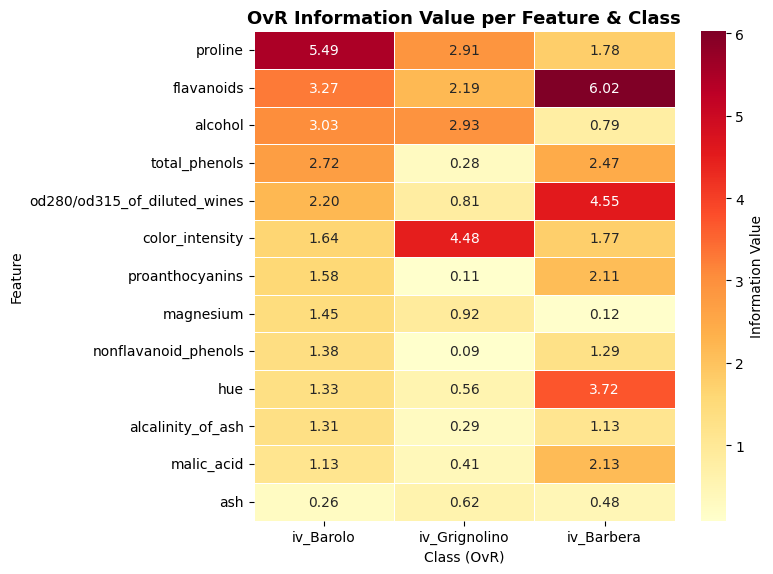

In [9]:
# Visualize per-class IV heatmap for all evaluated features
iv_cols = [f"iv_{c}" for c in CLASSES]
iv_heatmap_data = iv_df[iv_cols].sort_values(iv_cols[0], ascending=False)

plt.figure(figsize=(8, max(4, len(iv_df) * 0.45)))
sns.heatmap(
    iv_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Information Value"},
)
plt.title("OvR Information Value per Feature & Class", fontsize=13, fontweight="bold")
plt.ylabel("Feature")
plt.xlabel("Class (OvR)")
plt.tight_layout()
plt.show()

In [10]:
# Apply selector — drop low-IV / redundant features from both splits
df_dev_selected = selector.transform(df_dev_binned)
df_oot_selected = selector.transform(df_oot_binned)

print(f"Shape after selection — Dev: {df_dev_selected.shape}, OOT: {df_oot_selected.shape}")

Shape after selection — Dev: (124, 14), OOT: (54, 14)


---
## 5. ⚙️ WoE Feature Engineering with OvRWoeAdapter

`OvRWoeAdapter` trains one `WoeCalculator` per class (OvR) and applies WoE transformation. We use the `"per_class"` strategy, which produces one `{feature}_woe_{class}` column per combination — giving the model explicit per-class discriminative signals.

In [11]:
adapter = OvRWoeAdapter(classes=CLASSES)
adapter.fit(df_dev_selected, target=TARGET, columns=SELECTED_FEATURES)

# Transform both splits
df_dev_woe = adapter.transform(df_dev_selected, columns=SELECTED_FEATURES, strategy="per_class")
df_oot_woe = adapter.transform(df_oot_selected, columns=SELECTED_FEATURES, strategy="per_class")

# Identify the new WoE columns
woe_cols = [c for c in df_dev_woe.columns if any(c.endswith(f"_woe_{cls}") for cls in CLASSES)]
print(f"WoE columns generated: {len(woe_cols)}")
df_dev_woe[woe_cols].head(3)

WoE columns generated: 39

,flavanoids_woe_Barolo,proline_woe_Barolo,od280/od315_of_diluted_wines_woe_Barolo,color_intensity_woe_Barolo,hue_woe_Barolo,alcohol_woe_Barolo,total_phenols_woe_Barolo,malic_acid_woe_Barolo,proanthocyanins_woe_Barolo,magnesium_woe_Barolo,...,color_intensity_woe_Barbera,hue_woe_Barbera,alcohol_woe_Barbera,total_phenols_woe_Barbera,malic_acid_woe_Barbera,proanthocyanins_woe_Barbera,magnesium_woe_Barbera,nonflavanoid_phenols_woe_Barbera,alcalinity_of_ash_woe_Barbera,ash_woe_Barbera
0,-2.263129,-4.630979,-1.251222,-1.421288,-1.188701,-2.263129,-1.174577,-1.188701,-1.251222,-0.776114,...,0.093819,2.887027,0.855959,1.939645,1.746742,1.788414,0.093819,1.828420,2.927032,-0.101926
1,3.232672,2.052382,3.232672,-0.699153,3.232672,-0.035859,3.271139,1.161599,3.271139,-0.608181,...,-0.341499,-2.865546,-0.844451,-1.960305,-1.556862,-1.782498,-0.135756,-0.772992,0.559182,-1.004794
2,3.232672,3.232672,3.232672,-0.699153,3.232672,-2.263129,3.271139,1.161599,3.271139,3.411721,...,-0.341499,-2.865546,0.855959,-1.960305,-1.556862,-1.782498,0.322077,-0.772992,-0.612751,-0.049282


In [12]:
# IV Summary from the adapter
print("📊 OvR IV Summary from adapter:")
adapter.iv_summary()

📊 OvR IV Summary from adapter:


,iv_Barolo,iv_Grignolino,iv_Barbera,max_iv
feature,,,,
flavanoids,3.273970,2.186998,6.022433,6.022433
proline,5.487496,2.913297,1.783865,5.487496
od280/od315_of_diluted_wines,2.197507,0.809485,4.550675,4.550675
color_intensity,1.637869,4.477183,1.765791,4.477183
hue,1.327093,0.559779,3.719911,3.719911
alcohol,3.034122,2.933747,0.791422,3.034122
total_phenols,2.722772,0.280722,2.473763,2.722772
malic_acid,1.130531,0.410717,2.130698,2.130698
proanthocyanins,1.584839,0.108540,2.114599,2.114599


---
## 6. 🤖 Model Training — LightGBM Multiclass

We train a LightGBM classifier using the WoE-transformed features. `objective="multiclass"` natively handles multi-class prediction and outputs class probabilities.

In [13]:
X_dev = df_dev_woe[woe_cols]
y_dev = df_dev_woe[TARGET]

X_oot = df_oot_woe[woe_cols]
y_oot = df_oot_woe[TARGET]

model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(CLASSES),
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,
    random_state=42,
    verbosity=-1,
)
model.fit(X_dev, y_dev)
print("Model trained ✅")
print(f"Classes order: {model.classes_}")

Model trained ✅
Classes order: ['Barbera' 'Barolo' 'Grignolino']


---
## 7. 📊 Evaluation — MulticlassEvaluator

`MulticlassEvaluator` computes accuracy, precision, recall, F1, and log-loss. It also provides `confusion_matrix()` and `classification_report()` for deeper per-class analysis.

In [14]:
evaluator = MulticlassEvaluator(average="macro")

# Predict probabilities
proba_dev = model.predict_proba(X_dev)
proba_oot = model.predict_proba(X_oot)

# Wrap in DataFrame with class labels as columns
proba_dev_df = pd.DataFrame(proba_dev, columns=model.classes_)
proba_oot_df = pd.DataFrame(proba_oot, columns=model.classes_)

# Overall metrics
metrics_dev = evaluator.evaluate(y_dev.reset_index(drop=True), y_proba=proba_dev_df)
metrics_oot = evaluator.evaluate(y_oot.reset_index(drop=True), y_proba=proba_oot_df)

results = pd.DataFrame({"Dev": metrics_dev, "OOT": metrics_oot}).T
print("📊 Model Evaluation Metrics:")
results.round(4)

📊 Model Evaluation Metrics:


,accuracy,precision,recall,f1,log_loss
Dev,1.0000,1.0000,1.0000,1.0000,0.0011
OOT,0.9815,0.9848,0.9815,0.9827,0.1018


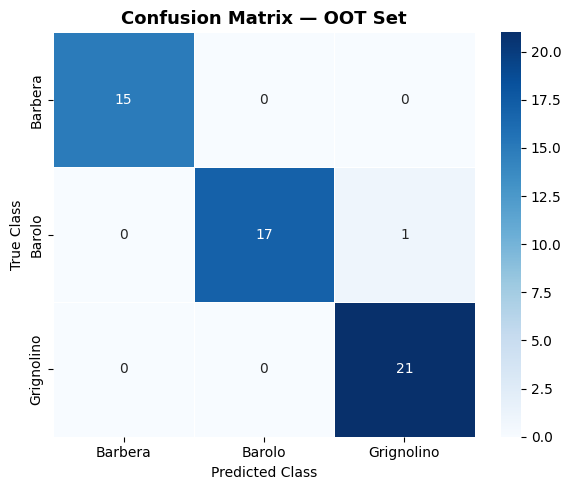

In [15]:
# Confusion Matrix — OOT set
y_oot_reset = y_oot.reset_index(drop=True)
y_pred_oot = proba_oot_df.idxmax(axis=1)

cm = evaluator.confusion_matrix(y_oot_reset, y_pred_oot)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
)
plt.title("Confusion Matrix — OOT Set", fontsize=13, fontweight="bold")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

In [16]:
# Per-class classification report
print("📋 Classification Report — OOT Set:")
print(evaluator.classification_report(y_oot_reset, y_pred_oot))

📋 Classification Report — OOT Set:
              precision    recall  f1-score   support

     Barbera       1.00      1.00      1.00        15
      Barolo       1.00      0.94      0.97        18
  Grignolino       0.95      1.00      0.98        21

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



---
## 8. 💾 Context Persistence — ProjectContext

`ProjectContext` centralises all modeling state in a single serializable object — bins, selected features, WoE maps, and metadata. This enables **reproducibility** and **serving consistency**: the same transformations applied during training can be reloaded and applied in production without re-fitting.

In [17]:
# Build context
ctx = ProjectContext()
ctx.task_type = TaskType.MULTICLASS
ctx.target = TARGET
ctx.selected_features = SELECTED_FEATURES
ctx.bins_map = bins_map
ctx.training_date = datetime.now()
ctx.metadata = {
    "classes": CLASSES,
    "iv_strategy": "max",
    "iv_threshold": 0.10,
    "n_estimators": 200,
    "dev_accuracy": round(metrics_dev["accuracy"], 4),
    "oot_accuracy": round(metrics_oot["accuracy"], 4),
}

print("📁 Context Summary:")
ctx.summary()

📁 Context Summary:


,Field,Value
0,Schema Version,2.0
1,Task Type,multiclass
2,Target,wine_class
3,Model Hash,None
4,Training Date,2026-05-05T00:07:26.587105
5,Features Selected,13
6,Metadata Keys,6
7,Bins Maps,13
8,WOE Maps,0


In [18]:
# Save context to disk
CTX_PATH = "multiclass_wine_context.joblib"
ctx.save(CTX_PATH)
print(f"Context saved to: {CTX_PATH} ✅")

Context saved to: multiclass_wine_context.joblib ✅


In [19]:
# Reload and validate
ctx_loaded = ProjectContext.load(CTX_PATH)
ctx_loaded.validate()

print(f"Task type      : {ctx_loaded.task_type}")
print(f"Target         : {ctx_loaded.target}")
print(f"Selected feats : {ctx_loaded.selected_features}")
print(f"Training date  : {ctx_loaded.training_date}")
print(f"Dev accuracy   : {ctx_loaded.metadata['dev_accuracy']}")
print(f"OOT accuracy   : {ctx_loaded.metadata['oot_accuracy']}")
print("\n✅ Context reloaded and validated successfully!")

Task type      : TaskType.MULTICLASS
Target         : wine_class
Selected feats : ['flavanoids', 'proline', 'od280/od315_of_diluted_wines', 'color_intensity', 'hue', 'alcohol', 'total_phenols', 'malic_acid', 'proanthocyanins', 'magnesium', 'nonflavanoid_phenols', 'alcalinity_of_ash', 'ash']
Training date  : 2026-05-05 00:07:26.587105
Dev accuracy   : 1.0
OOT accuracy   : 0.9815

✅ Context reloaded and validated successfully!


In [20]:
# In production: reload context and apply the same bins to new data
print("📦 Bins map ready for serving:")
for feat, edges in ctx_loaded.bins_map.items():
    print(f"  {feat}: {len(edges)} edges")

📦 Bins map ready for serving:
  alcohol: 4 edges
  malic_acid: 4 edges
  ash: 4 edges
  alcalinity_of_ash: 4 edges
  magnesium: 4 edges
  total_phenols: 4 edges
  flavanoids: 4 edges
  nonflavanoid_phenols: 4 edges
  proanthocyanins: 4 edges
  color_intensity: 4 edges
  hue: 4 edges
  od280/od315_of_diluted_wines: 4 edges
  proline: 4 edges


---
## ✅ Summary

This notebook demonstrated the complete `model_track` multiclass pipeline:

| Step | Tool | Purpose |
|------|------|---------|
| Data Auditing | `DataAuditor`, `TypeDetector` | Understand the data |
| Binning | `QuantileBinner` | Discretize continuous features |
| Feature Selection | `MulticlassSelector` | OvR IV + Cramer's V filter |
| WoE Engineering | `OvRWoeAdapter` | Per-class WoE transformation |
| Modeling | `LightGBM` | Multiclass classification |
| Evaluation | `MulticlassEvaluator` | Accuracy, F1, confusion matrix |
| Persistence | `ProjectContext` | Save/reload modeling state |

### Key Advantages of the OvR Approach
- **Interpretability**: Each feature's IV is computed **per class**, revealing which variables are most predictive for each wine type.
- **Selectivity**: The `iv_strategy` parameter lets you tune how strict the feature filter is.
- **Consistency**: All transformations (bins, WoE maps) are stored in `ProjectContext` for serving.

> 📘 See also: [OvRWoeAdapter](../src/model_track/woe/ovr_adapter.py) | [MulticlassSelector](../src/model_track/stats/multiclass_selection.py)